<a href="https://colab.research.google.com/github/ChanceResearcher/skills-review-pull-requests/blob/main/GNR_KR_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import numpy as np
import random
import matplotlib.pyplot as plt
from fractions import Fraction

#The same seed I saw the models using.
random.seed(12345)

In [82]:
# Simulation of a GNR (Growing Network with Redirection),
# returns the average number of nodes with k,l connections as third output:
def GNR_SimulationV2(NumNodes, r_probability):
    NumNodes += 1
    #Initialize the arrays for the simulation.

    #Index will be the Node ID, Column will be the node's connections.
    NodesDegreeSim = np.ones(NumNodes, dtype=int)
    #Index will be the Node ID, Column will be the node connected to for each newcomer node.
    NodeConnectionsSim = np.zeros(NumNodes, dtype=int)
    #First index is k, second index is L.
    Nkl = np.zeros([NumNodes, NumNodes], dtype=int)
    #Number of nodes with k connections.
    N_k = np.zeros(NumNodes)
    #First index is node count, Second index is k connections of node with ID number index 2.
    NodesAtTime = np.zeros([NumNodes, NumNodes], dtype=int)

    #Initial Conditions: Triangular network of 3 nodes, each connected to the other two.
    NodesDegreeSim[1:4] += 1 #All three nodes start with 2 connections.
    NodeConnectionsSim[1] = 2 #Node 0 connects to Node 1.
    NodeConnectionsSim[2] = 3 #Node 1 connects to Node 2.
    NodeConnectionsSim[3] = 1 #Node 2 connects to Node 0.
    N_k[2] = 3
    NodesAtTime[3,:] = N_k
    Nkl[1,3] = 1
    Nkl[2,3] = 1
    Nkl[3,2] = 1
    Nkl[2,2] = 1
    #The inital conditions represent this: 1 > 2 > 3 > 1...wrap around, circular loop.


    #For each new node, randomly select a node to connect to, and with probability r,
    #connect to the ancestor of that node instead.
    for NodeID in range(4, NumNodes):
        N_k = np.zeros(NumNodes)
        NewNodeSim = np.random.randint(1, NodeID ) #Randomly select a node to connect to.
        if random.random() < r_probability: #With probability r, connect to the ancestor of the chosen node.
            NewNodeSim = NodeConnectionsSim[NewNodeSim] #Connect to the ancestor of the chosen node.
        NodeConnectionsSim[NodeID] = NewNodeSim #Add the new node to the list of connections for the chosen node.
        NodesDegreeSim[NewNodeSim] += 1 #Add one to the specific degree count of the chosen node, for the new connection.
        for i in range(1,NumNodes):
            N_k[NodesDegreeSim[i]] += 1
        NodesAtTime[NodeID,:] = N_k

    for A in range(0,NumNodes):
        nodeK = NodesDegreeSim[A]
        ancestorL = NodesDegreeSim[NodeConnectionsSim[A]]
        Nkl[nodeK, ancestorL] += 1

#Return the number of nodes with k connections for every value of N up to Nmax.
#Return the Node array with k value stashed for every node.
#Return Nkl, the number of nodes with k connections connected to an ancestor of l connections.
    return NodesAtTime, NodesDegreeSim, Nkl

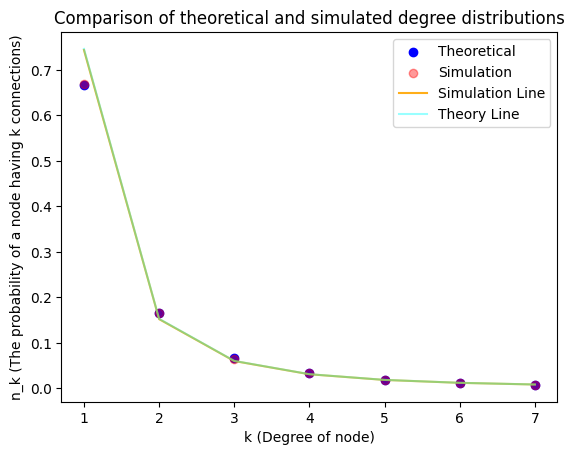

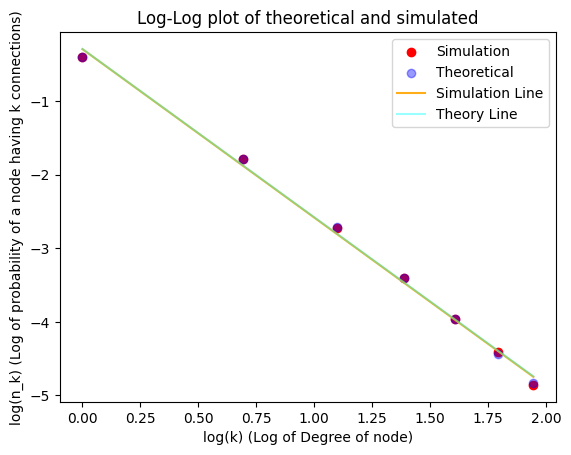

In [83]:
# Proof of model working:
#Compare simulation n_k to theory n_k = 4 / (k * (k + 1) * (k + 2)) for r = 0.5 (Exactly when a GNR matches a GN).

num_nodes_proof = 1000
r_proof = 0.5
trials_proof = 100
k_end_proof = 7  # Example value, adjust as needed. Max value of k to plot.
N_k_sim_Proof = 0
NodesIDk = 0
sumNk = np.zeros([num_nodes_proof+1,num_nodes_proof+1])
sumK = 0
trackN_k = 0
FinalN_k = 0

# Run the simulation for a number of trials.
for t in range(0,trials_proof):
    N_k_s, NodesIDk, Nkl = GNR_SimulationV2(num_nodes_proof, r_proof)
    sumNk = sumNk + N_k_s
    sumK += NodesIDk
N_k_sim_Proof = sumNk / trials_proof
NodesIDk = sumK / trials_proof

# Normalize the number of nodes with k connections by the total number of nodes,
# to get the probability of nodes with k connections.
n_k_sim_Proof = N_k_sim_Proof / num_nodes_proof

# Theoretical distribution for the proof case.
n_k_theory = np.array([ 4 / (k_i * (k_i + 1) * (k_i + 2)) for k_i in range(1, len(n_k_sim_Proof)+1)], dtype=float)

# Prepare data for ploting.
k = np.arange(1, k_end_proof + 1)
y_theory = n_k_theory[0:k_end_proof]
y_sim = n_k_sim_Proof[-1,1:k_end_proof+1]

# Log-Log Data Set
k_log = np.log(k)
y_log_sim = np.log(y_sim)
y_log_theory = np.log(y_theory)

# Linear Regression of Simulation and Theory for Log-Log Plot

Simulation_slope,Simulation_intercept = np.polyfit(k_log, y_log_sim,1)
Theory_slope,Theory_intercept = np.polyfit(k_log, y_log_theory,1)
Sim_b = np.exp(Simulation_intercept)
Theory_b = np.exp(Theory_intercept)

# Scatter Plot of Regression of Simulation and Theory
plt.figure()
plt.scatter(k, y_theory, color="blue", label="Theoretical")
plt.scatter(k, y_sim, color="red", label="Simulation", alpha=0.4)
plt.plot(k, Sim_b * (k**Simulation_slope), color="orange", label="Simulation Line", alpha=0.9)
plt.plot(k, Theory_b * (k**Theory_slope), color="cyan", label="Theory Line", alpha=0.4)
plt.xlabel("k (Degree of node)")
plt.ylabel("n_k (The probability of a node having k connections)")
plt.title("Comparison of theoretical and simulated degree distributions")
plt.legend()
plt.show()

# Log-Log Plot
plt.figure()
plt.scatter(k_log, y_log_sim, color="red", label="Simulation")
plt.scatter(k_log, y_log_theory, color="blue", label="Theoretical", alpha=0.4)
plt.plot(k_log, Simulation_slope * k_log + Simulation_intercept, color="orange", label="Simulation Line", alpha=0.9)
plt.plot(k_log, Theory_slope * k_log + Theory_intercept, color="cyan", label="Theory Line", alpha=0.4)
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_k) (Log of probability of a node having k connections)")
plt.title("Log-Log plot of theoretical and simulated")
plt.legend()
plt.show()

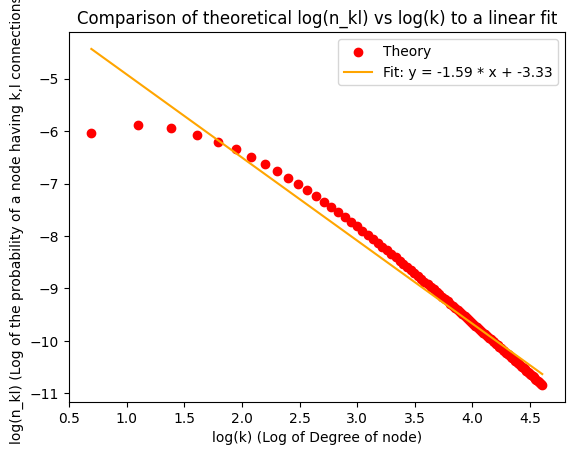

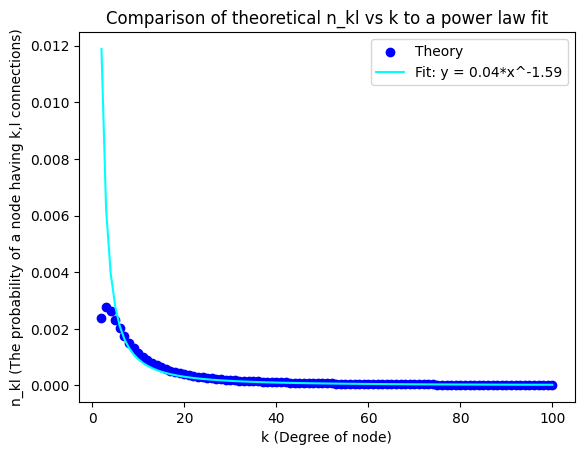

In [84]:
#PART A - TEST 1/4: N=100 Reason: To show plot forms.

N = 100
L_min = 2
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[L_single,L_min:])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[L_single,L_min:], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


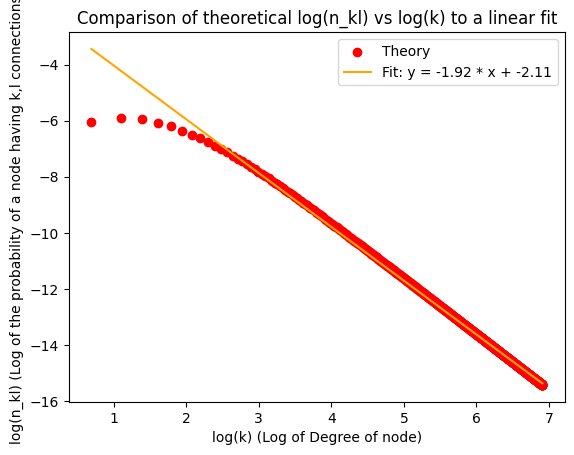

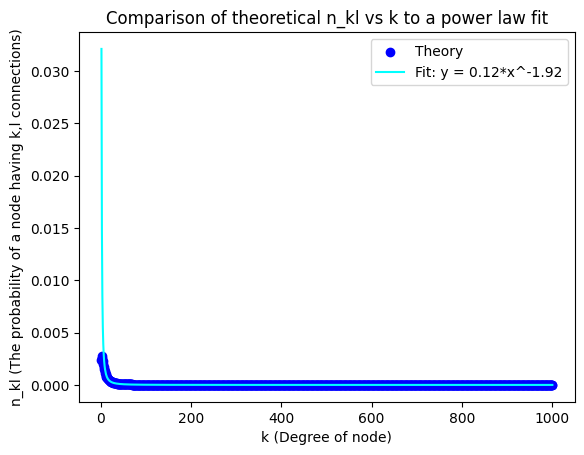

In [85]:
#PART A - TEST 2/3: N=1000 Reason: To show initial point for the slope of the line log(n_kl)/log(l).
# This slope represents the rate of change of log(n_kl) with respect to log(l).
# The slope value will also match the exponent on l^slope, when graphing n_kl vs l.
# Note how the slope value beings to approach -2.

N = 1000
L_min = 2
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[L_single,L_min:])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[L_single,L_min:], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


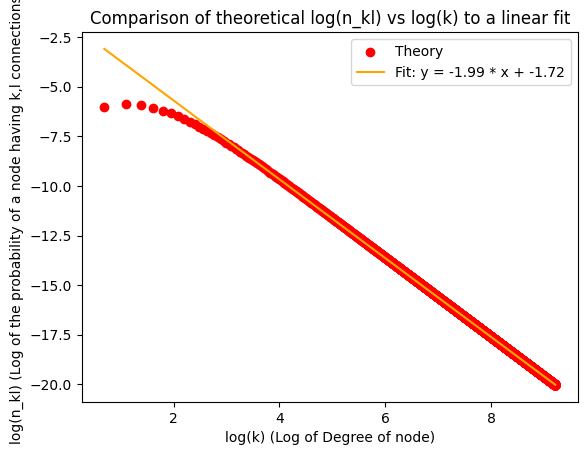

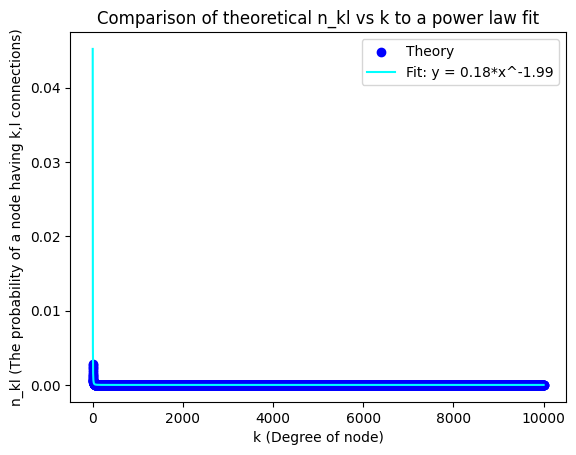

In [86]:
#PART A - TEST 3/3: N=10000 Reason: To show the slope of the line log(n_kl)/log(l) approaches -2.
# This slope represents the rate of change of log(n_kl) with respect to log(l).
# The slope value will also match the exponent on l^slope, when graphing n_kl vs l.
# Note how the slope value approachs -2 much more closely than earlier total node values.

N = 10000
L_min = 2
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[L_single,L_min:])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[L_single,L_min:], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


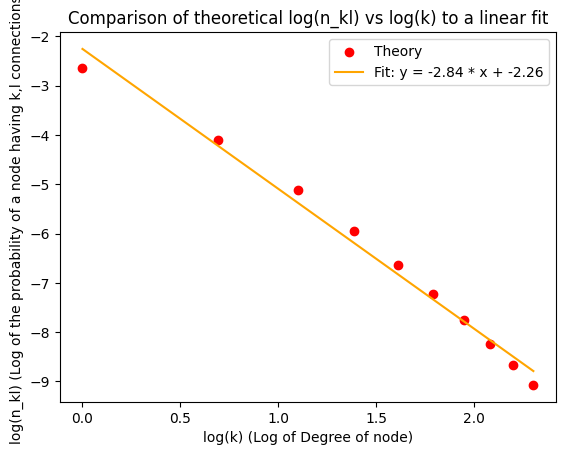

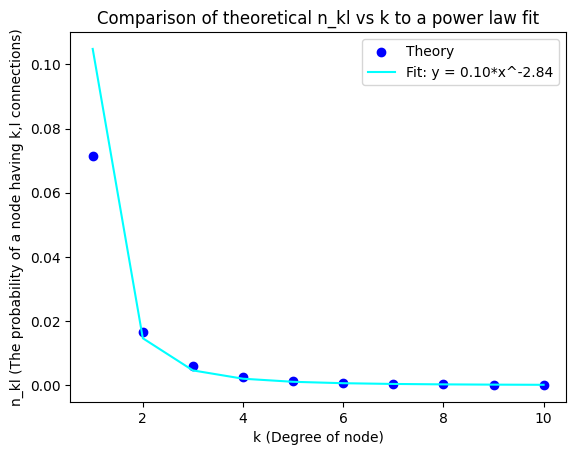

In [87]:
#PART B - TEST 1/4: N=10 Reason: To show plot forms.

N = 10
L_min = 1
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[1:,L_single])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[1:,L_single], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


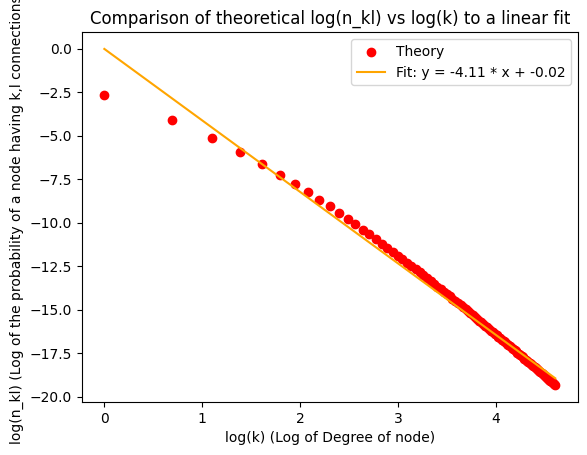

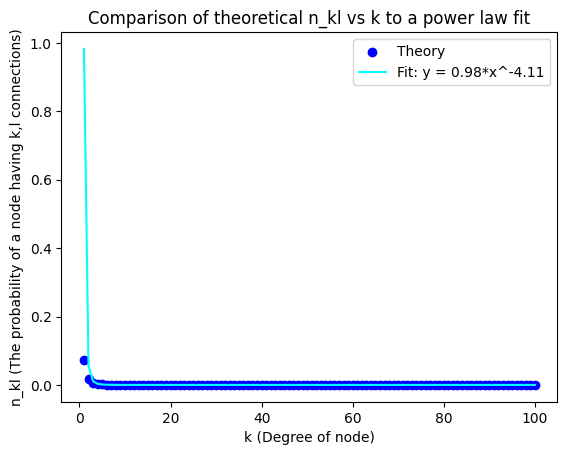

In [88]:
#PART B - TEST 2/4: N=100 Reason: To show initial point for the slope of the line log(n_kl)/log(k).
# This slope represents the rate of change of log(n_kl) with respect to log(k).
# The slope value will also match the exponent on k^slope, when graphing n_kl vs k.
# Note how the slope value beings to approach -5.

N = 100
L_min = 1
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[1:,L_single])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[1:,L_single], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


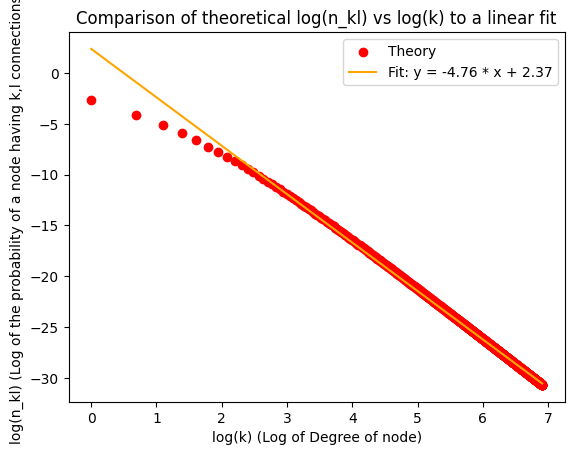

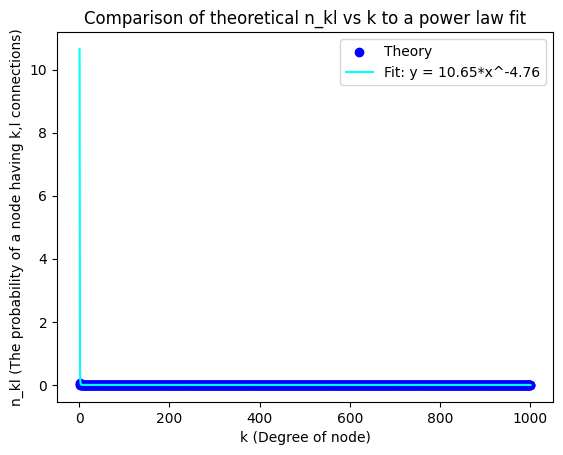

In [89]:
#PART B - TEST 3/4: N=1000 Reason: To show how the slope approaches -5 as N increases.
# This slope represents the rate of change of log(n_kl) with respect to log(k).
# The slope value will also match the exponent on k^slope, when graphing n_kl vs k.
# Note how the slope value approachs -5.

N = 1000
L_min = 1
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[1:,L_single])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[1:,L_single], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()


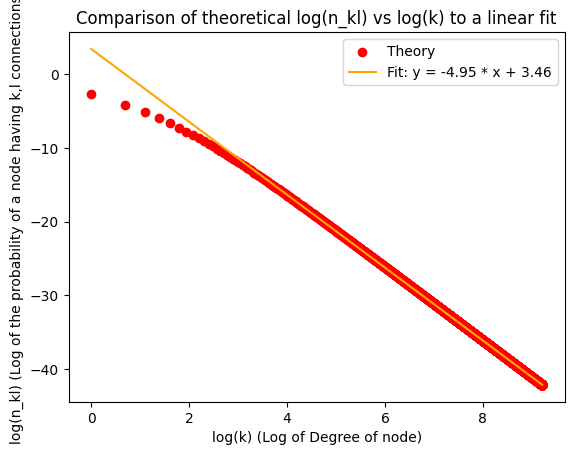

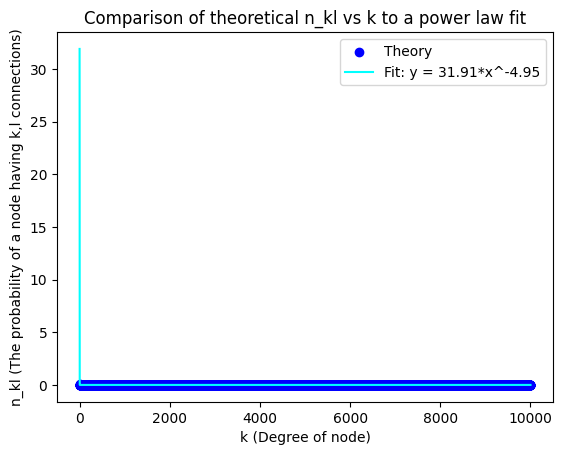

In [90]:
#PART B - TEST 4/4: N=10000 Reason: To show the slope of the line log(n_kl)/log(k) approaches -5.
# This slope represents the rate of change of log(n_kl) with respect to log(k).
# The slope value will also match the exponent on k^slope, when graphing n_kl vs k.
# Note how the slope value approachs -5 much more closely than earlier total node values.

N = 10000
L_min = 1
L_single = 4

nkl = np.zeros([N+1,N+1])
n_k_theory = np.zeros(N+1)
L = np.arange(0, N+1)
for k in range(1,N+1):
  n_k_theory[k] = 4 / (k * (k + 1) * (k + 2))
  for l in range(2,N+1):
        nkl[k,l] = ((4*(l-1)) / (k*(k+1)*(k+l)*(k+l+1)*(k+l+2))) + ((12*(l-1)) / (k*(k+l-1)*(k+l)*(k+l+1)*(k+l+2)))

L_log = np.log(L[L_min:])
y_log_sim = np.log(nkl[1:,L_single])

m,b = np.polyfit(L_log, y_log_sim, 1)
unlog_b = np.exp(b)

plt.figure()
plt.scatter(L_log, y_log_sim, color="red", label="Theory")
plt.plot(L_log, m * L_log + b, color="orange", label=f"Fit: y = {m:.2f} * x + {b:.2f}")
plt.xlabel("log(k) (Log of Degree of node)")
plt.ylabel("log(n_kl) (Log of the probability of a node having k,l connections)")
plt.title("Comparison of theoretical log(n_kl) vs log(k) to a linear fit")
plt.legend()

plt.figure()
plt.scatter(L[L_min:], nkl[1:,L_single], color="blue", label="Theory")
plt.plot(L[L_min:], unlog_b * (L[L_min:]**m), color="cyan", label=f"Fit: y = {unlog_b:.2f}*x^{m:.2f}")
plt.xlabel("k (Degree of node)")
plt.ylabel("n_kl (The probability of a node having k,l connections)")
plt.title("Comparison of theoretical n_kl vs k to a power law fit")
plt.legend()
plt.show()
